In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Social_Network_Ads.csv')
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
79,15655123,Female,26,17000,0
45,15639277,Male,23,20000,0
321,15611191,Female,53,82000,1
325,15695679,Female,41,60000,0
386,15724150,Female,49,39000,1


In [4]:
df = df.drop('User ID', axis=1)

In [5]:
df = pd.get_dummies(df, drop_first=False).astype(int)

In [6]:
df

,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
0,19,19000,0,0,1
1,35,20000,0,0,1
2,26,43000,0,1,0
3,27,57000,0,1,0
4,19,76000,0,0,1
...,...,...,...,...,...
395,46,41000,1,1,0
396,51,23000,1,0,1
397,50,20000,1,1,0
398,36,33000,0,0,1


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X = df.drop('Purchased', axis=1)
y = df['Purchased']

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()

In [11]:
from sklearn.preprocessing import PolynomialFeatures

In [12]:
poly_converter = PolynomialFeatures(degree=2, include_bias=False)

In [13]:
poly_features = poly_converter.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=42)

In [15]:
scaled_x_train = scaler.fit_transform(X_train)
scaled_x_test = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
model = LogisticRegression()

In [18]:
import warnings
warnings.filterwarnings('ignore')

model.fit(scaled_x_train,y_train)

LogisticRegression()

In [19]:
y_pred = model.predict(scaled_x_test)

In [20]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix, roc_auc_score, PrecisionRecallDisplay, classification_report

In [21]:
accuracy_score(y_test, y_pred)

0.9333333333333333

In [22]:
confusion_matrix(y_test, y_pred)

array([[71,  2],
       [ 6, 41]])

In [23]:
roc_auc_score(y_test, y_pred)

0.9224715826289712

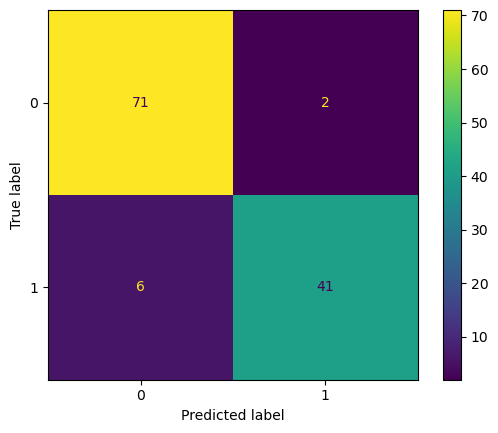

In [24]:
ConfusionMatrixDisplay.from_estimator(model, scaled_x_test, y_test);

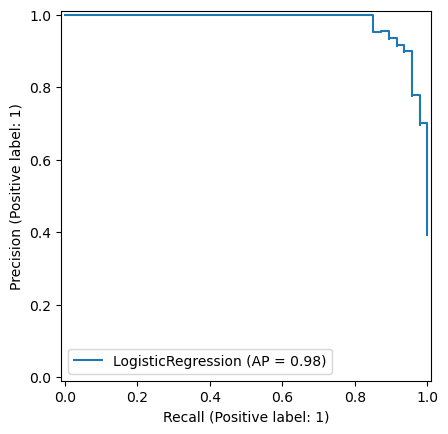

In [25]:
PrecisionRecallDisplay.from_estimator(model, scaled_x_test, y_test);

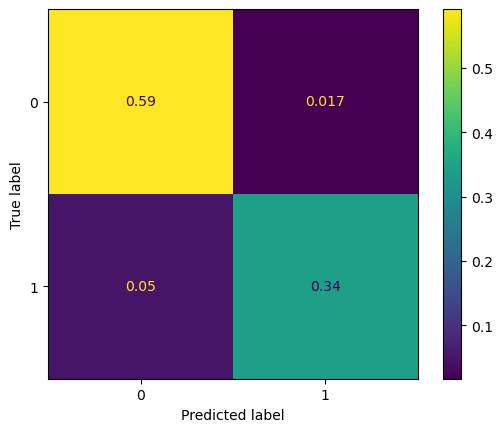

In [26]:
ConfusionMatrixDisplay.from_estimator(model, scaled_x_test, y_test, normalize='all');

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95        73
           1       0.95      0.87      0.91        47

    accuracy                           0.93       120
   macro avg       0.94      0.92      0.93       120
weighted avg       0.93      0.93      0.93       120



In [28]:
df.sample(5)

,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
133,21,68000,0,1,0
211,52,150000,1,0,1
367,46,88000,1,0,1
50,24,32000,0,1,0
8,25,33000,0,0,1


In [31]:
# Example new user: Gender must already be encoded the same way as X
new_user = pd.DataFrame([{
    'Age': 52,
    'EstimatedSalary': 150000,
    'Gender_Female': 0,
    'Gender_Male': 1
}])

# 2. Create degree-2 polynomial features
new_user_poly = poly_converter.transform(new_user)

# 3. Scale polynomial features using the scaler fitted on X_train
new_user_poly_scaled = scaler.transform(new_user_poly)

# 4. Predict
model.predict(new_user_poly_scaled)

array([1])